In [1]:
# conda activate chronocell

import sys
import glob
import pickle
import numpy as np
import pandas as pd
from functools import reduce

sys.path.append("/mnt/lareaulab/reliscu/programs/FGP_2024")
sys.path.append("code")

import Chronocell
from impute_protein import *

In [2]:
prefix = "janssens_2025_preprint_Chronocell_eLNPs_var>1.5_204_fitted_genes"

In [3]:
# Get traj object from running Chronocell
import pickle
with open(f"data/{prefix}_traj_WS.pkl", "rb") as f:
    traj = pickle.load(f)

In [4]:
t = traj.t

In [5]:
# Y = traj.X
Q = traj.Q[:, 0, :] 
# tau = traj.tau # State transition times (global)
#  = traj.t
# theta = traj.theta
# topo = traj.topo
# state_grid = np.searchsorted(tau, t, side="left") - 1
# state_grid[0] = 0 

## Get genes of interest

In [6]:
genes = pd.read_csv(f"data/{prefix}.csv")
mapped_identifiers = pd.read_csv("data/janssens_2025_preprint_author_counts_eLNP_RNA_vs_ADT_corrs.csv")
gene_idx = genes['Gene_symbol'].isin(mapped_identifiers['Gene']).tolist()

In [7]:
genes.iloc[gene_idx]['Gene_symbol'].tolist()

['Cxcr4',
 'Icos',
 'Cd48',
 'Sbno2',
 'Cd24a',
 'Cd63',
 'Cd68',
 'Ccr7',
 'Havcr2',
 'Ighm',
 'Irf4',
 'Cd83',
 'Lgals3',
 'Il7r',
 'Ly6e',
 'Cd86',
 'Cd200',
 'Cd80',
 'Btla',
 'Ms4a1',
 'Cd274',
 'Fas',
 'Dpp4',
 'Itga4',
 'Procr',
 'Cd1d1',
 'Vcam1',
 'Tnfrsf4',
 'Cd36',
 'Sbno1',
 'Flt3',
 'Cd38',
 'Kit',
 'Cd9',
 'Klrk1',
 'Cd8a',
 'Clec12a',
 'Clec9a',
 'Pirb',
 'Il4ra',
 'Itgal',
 'Itgax',
 'Bst2',
 'Lamp1',
 'Itgb1',
 'Xcr1',
 'Icam1']

## Get half-life data

In [11]:
data_dir = "/mnt/lareaulab/reliscu/projects/Chronocell/data/experimental_parameters/protein_degradation_rates"
file_list = glob.glob(f"{data_dir}/*standardized.csv")
subset_columns = ['Gene', 'Half-life']

df_list = []
for file in [file for file in file_list if "Mouse" in file]:
    df = pd.read_csv(file)
    study = df['Study'].iloc[0]
    cell_type = df['Cell_type'].iloc[0]
    df = df[subset_columns]
    df = df.rename(columns={"Half-life": f"Half-life_{study}_{cell_type}", 
                            "Cell_type": f"Cell_type_{study}"}) 
    df_list.append(df)

In [12]:
df_list[0].head()

,Gene,Half-life_McShane2016_NIH3T3 fibroblasts
0,Cul4b,31.378265
1,Dhx8,28.700000
2,Znf335,3.599724
3,Arfgef2,24.371302
4,Cdc27,21.057713


In [13]:
df = reduce(lambda x, y: pd.merge(x, y, on="Gene", how="outer"), df_list)


In [14]:
df.shape

(20227, 8)

## Subset half-life data to genes of interest

In [15]:
df_subset = df.loc[df['Gene'].isin(genes.iloc[gene_idx]['Gene_symbol'])]

In [16]:
df_subset.reset_index(drop=True)

,Gene,Half-life_McShane2016_NIH3T3 fibroblasts,Half-life_Schwanhausser2011_NIH3T3 fibroblasts,Half-life_Fornasiero2018_Leg-muscle,Half-life_Matsuda2024_Induced presomitic mesoderm cells,Half-life_Cambridge2011_C2C12 myoblasts,Half-life_Mathieson2018_Embryonic neurons,Half-life_Fornasiero2018_Heart
0,Bst2,NaN,8.89,NaN,NaN,NaN,NaN,NaN
1,Cd63,19.953640,57.49,NaN,NaN,NaN,NaN,NaN
2,Cd9,NaN,32.19,NaN,NaN,NaN,NaN,NaN
3,Itgb1,63.400000,11.75,60.0,NaN,28.3,NaN,62.88
4,Lamp1,NaN,30.18,NaN,NaN,38.7,NaN,35.04
5,Lgals3,115.005279,60.99,NaN,NaN,44.3,NaN,NaN
6,Procr,NaN,22.27,NaN,NaN,NaN,NaN,NaN
7,Sbno1,10.793772,14.04,NaN,NaN,NaN,NaN,NaN
8,Sbno2,NaN,107.96,NaN,NaN,NaN,NaN,NaN
9,Vcam1,12.751839,18.18,NaN,NaN,15.5,NaN,NaN


## Plot distribution of half-life estimates

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker


/tmp/ipykernel_3905910/1397995706.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_3905910/1397995706.py:23: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


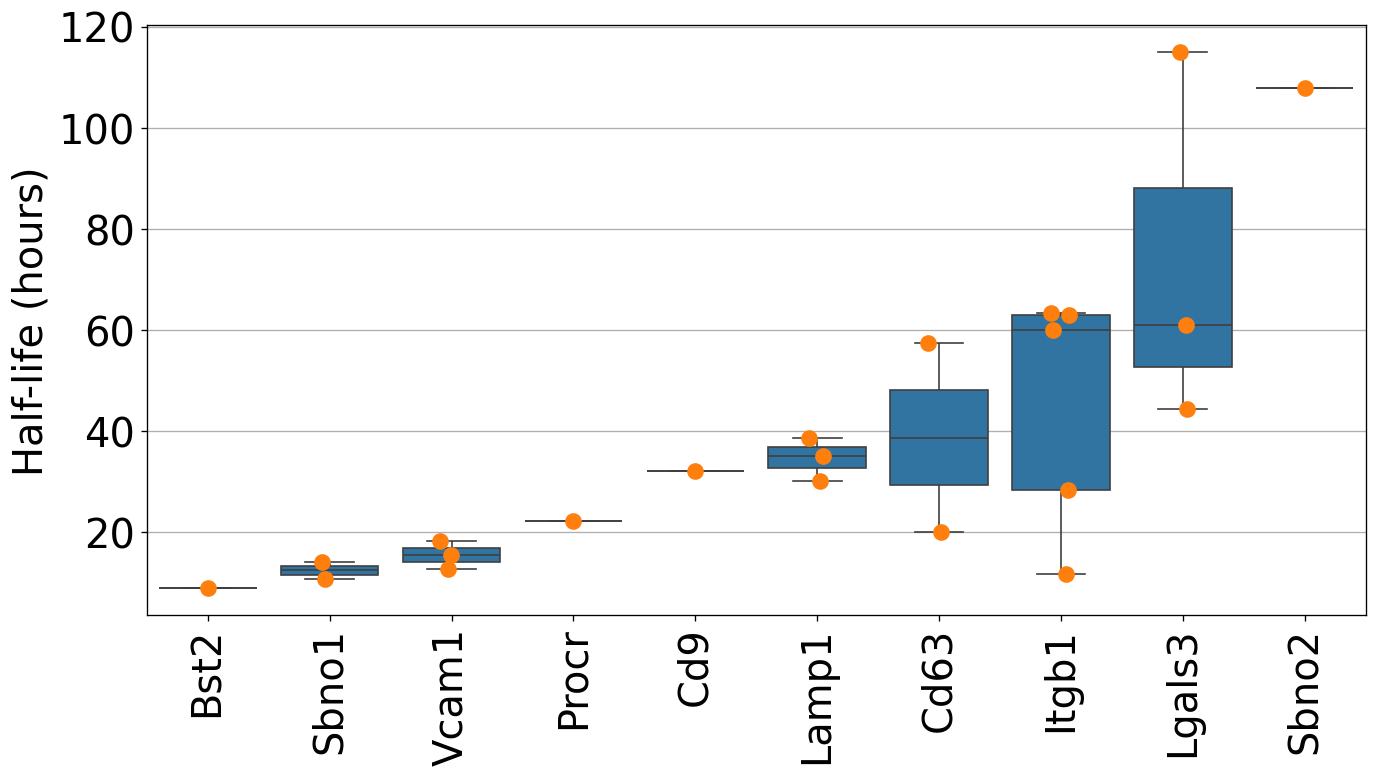

In [46]:
import matplotlib.ticker as mticker

# order genes by mean half_life (ascending). Use .sort_values(ascending=False) for descending.
gene_order = (long.groupby(id_col)["half_life"]
                  .mean()
                  .sort_values()
                  .index
                  .tolist())

fig, ax = plt.subplots(figsize=(12, 7), dpi=120)

ax.yaxis.set_major_locator(mticker.MultipleLocator(20))
ax.grid(True, which="major", axis="y")

sns.boxplot(data=long, x=id_col, y="half_life", order=gene_order, ax=ax)
sns.stripplot(data=long, x=id_col, y="half_life",
              order=gene_order, jitter=True, alpha=1, size=10, ax=ax)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_xlabel("")
ax.set_ylabel("Half-life (hours)")

plt.tight_layout()
plt.show()


In [ ]:
import seaborn as sns

## Convert half-life to degradation rate

In [ ]:
half_life_cols = [col for col in df_subset.columns if "Half-life" in col]
df_deg = np.log(2)/df_subset[half_life_cols]
median_deg = np.nanmedian(df_deg, axis=1)

In [21]:
df_subset['Gene']

1962       Bst2
2973       Cd63
2976        Cd9
7683      Itgb1
8793      Lamp1
8875     Lgals3
12968     Procr
16288     Sbno1
16289     Sbno2
18975     Vcam1
Name: Gene, dtype: object

## Impute protein

In [22]:
Q.shape

(21325, 100)

In [23]:
n_genes = df_subset.shape[0]
n_cells = Q.shape[0]

P = np.full((n_cells, n_genes), -1)

for idx, gene in enumerate(df_subset['Gene']):
    file_path = f"data/RNA_history_per_gene/{prefix}_{gene}_S_RNA_history.pkl"

    with open(file_path, "rb") as f:
        X_bw = pickle.load(f)
    
    deg_rate = median_deg[idx]    
    
    P[:, idx] = impute_protein(X_bw, Q, t, deg_rate, transl_rate=1)

In [24]:
P.shape

(21325, 10)

In [25]:
P_df = pd.DataFrame(P, columns=df_subset['Gene'].tolist())
P_df.head()


,Bst2,Cd63,Cd9,Itgb1,Lamp1,Lgals3,Procr,Sbno1,Sbno2,Vcam1
0,10,160,1,85,96,709,0,0,0,0
1,9,157,50,84,95,716,1,0,0,0
2,11,164,46,86,98,707,0,0,0,0
3,12,165,0,85,98,706,0,0,0,0
4,9,158,49,84,96,717,0,0,0,0


In [20]:
P_df = pd.DataFrame(P, columns=df_subset['Gene'].tolist())
P_df.head()


,Bst2,Cd63,Cd9,Itgb1,Lamp1,Lgals3,Procr,Sbno1,Sbno2,Vcam1
0,10,160,1,85,96,709,0,0,0,0
1,9,157,50,84,95,716,1,0,0,0
2,11,164,46,86,98,707,0,0,0,0
3,12,165,0,85,98,706,0,0,0,0
4,9,158,49,84,96,717,0,0,0,0


In [21]:
P_df.to_csv(f"data/{prefix}_RNA_history_imputed_protein.csv", index=False)